In [53]:
import pandas as pd
import numpy as np

df_vendas = pd.read_csv("vendas_tech.csv", low_memory=False)
display(df_vendas)
df_gerentes = pd.read_excel("gerentes_lojas.xlsx")
display(df_gerentes)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


,Loja,Gerente,Meta_Mensal
0,São Paulo,Carlos,50000
1,Rio de Janeiro,Fernanda,60000
2,Curitiba,Roberto,45000
3,Belo Horizonte,Juliana,55000
4,Recife,Marcos,48000
5,Porto Alegre,Pedro,42000
6,Salvador,Ana,52000


In [54]:
#inspeção
display(df_vendas.shape)
#display(df_vendas.head(15))
#display(df_vendas.tail(15))
#display(df_vendas.sample(15))
#display(df_vendas.columns)
display(df_vendas.info())
display(df_vendas.describe())


(100100, 8)

<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  str    
 2   Loja            98099 non-null   str    
 3   Produto         100100 non-null  str    
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  str    
 7   Data_Base       1 non-null       str    
dtypes: float64(1), int64(2), str(5)
memory usage: 6.1 MB


None

,ID_Pedido,Preco_Unitario,Qtd
count,100100.000000,100100.000000,100100.000000
mean,50004.810180,2000.204595,1.499101
std,28866.872543,1841.050733,1.241605
min,1.000000,40.000000,1.000000
25%,25008.750000,120.000000,1.000000
50%,50004.500000,1200.000000,1.000000
75%,75002.250000,3200.000000,1.000000
max,100000.000000,5500.000000,10.000000


In [55]:
#tratamento de dados
#excluir
#display(df_vendas["Loja"])
#display(df_vendas[["Loja","Cliente"]])

#colunas
df_analise = df_vendas.drop(columns="Data_Base")

#nulos
#df_analise = df_analise.dropna()
df_analise["Loja"] = df_analise["Loja"].fillna("Online")

#tipos de dados
df_analise["Data"] = pd.to_datetime(df_analise["Data"], format="%Y-%m-%d")

#padronização
df_analise["Loja"] = df_analise["Loja"].str.strip()
df_analise["Loja"] = df_analise["Loja"].str.title()

df_gerentes["Loja"] = df_gerentes["Loja"].str.strip()
df_gerentes["Loja"] = df_gerentes["Loja"].str.title()


#encadeamento
#df_analise["Loja"] = df_analise["Loja"].fillna("Online").str.strip().str.title()

#duplicatas
df_analise = df_analise.drop_duplicates()



display(df_analise)
display(df_analise.info())




,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100000 non-null  int64         
 1   Data            100000 non-null  datetime64[us]
 2   Loja            100000 non-null  str           
 3   Produto         100000 non-null  str           
 4   Preco_Unitario  100000 non-null  float64       
 5   Qtd             100000 non-null  int64         
 6   Cliente         100000 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 5.3 MB


None

In [56]:
#criação de colunas

#faturamento
df_analise["Faturamento"] = df_analise["Qtd"] * df_analise["Preco_Unitario"]

#forma de venda
df_analise["Forma_Venda"] = np.where(df_analise["Loja"] == "Online", "E-commerce", "Loja Física")

#regiao
display(df_analise["Loja"].unique())

def definir_regiao(loja):
    dict_regioes = {
        "São Paulo": "Sudeste",
        "Belo Horizonte": "Sudeste",
        "Online" : "Online",
        "Rio De Janeiro": "Sudeste",
        "Salvador": "Nordeste",
        "Recife": "Nordeste",
        "Curitiba": "Sul",
        "Porto Alegre": "Sul"
    }
    return dict_regioes[loja]

df_analise["Regiao"] = df_analise["Loja"].map(definir_regiao)

display(df_analise)
display(df_analise.isna().sum())
#display(df_analise.info())

<StringArray>
[     'São Paulo', 'Belo Horizonte',         'Online', 'Rio De Janeiro',
       'Salvador',         'Recife',       'Curitiba',   'Porto Alegre']
Length: 8, dtype: str

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Loja Física,Sudeste
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Loja Física,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,E-commerce,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Loja Física,Sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Loja Física,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Loja Física,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Loja Física,Sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Loja Física,Sul
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Loja Física,Sul


ID_Pedido         0
Data              0
Loja              0
Produto           0
Preco_Unitario    0
Qtd               0
Cliente           0
Faturamento       0
Forma_Venda       0
Regiao            0
dtype: int64

In [57]:
#analisar -> filtrar

df_analise = df_analise.sort_values(by="Data")
df_analise = df_analise.reset_index(drop=True)

#.loc: id do pedio
id_pedido = 4
loja = df_analise.loc[df_analise["ID_Pedido"]==4,"Loja"].values[0]
produto = df_analise.loc[df_analise["ID_Pedido"]==4,"Produto"].values[0]
cliente = df_analise.loc[df_analise["ID_Pedido"]==4,"Cliente"].values[0]

print(loja)
print(produto)
print(cliente)

#.iloc
id_pedido = 4
loja = df_analise.iloc[3,2]
produto = df_analise.iloc[3,3]
cliente = df_analise.iloc[3,6]

print(loja,produto,cliente)

#condicional
df_id_pedido_4 = df_analise[df_analise["ID_Pedido"]==4]

#exportar pedaços da base
df_vendas_sp = df_analise[df_analise["Loja"]=="São Paulo"]
df_vendas_sp.to_csv("Vendas_SP.csv", index=False)

#exportar as vendas de 2024
df_vendas_2024 = df_analise[df_analise["Data"].dt.year==2024]

#duplas condições
#df_vendas_HDMI_SUL = df_analise[df_analise["Produto"]=="Cabo HDMI"]
#df_vendas_HDMI_SUL = df_analise[df_analise["Regiao"]=="Sul"]
df_vendas_HDMI_SUL = df_analise[(df_analise["Regiao"]=="Sul") & (df_analise["Produto"]=="Cabo HDMI")]


display(df_vendas_HDMI_SUL)
#display(df_analise)
#display(df_id_pedido_4)

Rio De Janeiro
Mouse Gamer
Cliente_17343
São Paulo Teclado Mecânico Cliente_22822


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
15,70138,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_9348,40.0,Loja Física,Sul
50,97659,2023-01-01,Curitiba,Cabo HDMI,40.0,1,Cliente_58,40.0,Loja Física,Sul
83,42051,2023-01-01,Curitiba,Cabo HDMI,40.0,10,Cliente_16622,400.0,Loja Física,Sul
97,37130,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_22886,40.0,Loja Física,Sul
98,49140,2023-01-01,Porto Alegre,Cabo HDMI,40.0,1,Cliente_24445,40.0,Loja Física,Sul
...,...,...,...,...,...,...,...,...,...,...
99878,35127,2024-12-30,Curitiba,Cabo HDMI,40.0,2,Cliente_20687,80.0,Loja Física,Sul
99926,75695,2024-12-30,Porto Alegre,Cabo HDMI,40.0,1,Cliente_29587,40.0,Loja Física,Sul
99931,47774,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_14363,80.0,Loja Física,Sul
99950,64473,2024-12-30,Porto Alegre,Cabo HDMI,40.0,2,Cliente_11598,80.0,Loja Física,Sul


In [58]:
#analise por agrupamento
#display(df_analise)

#ranking de faturamento por lojas
analise_lojas = df_analise[["Loja","Faturamento"]].groupby("Loja").sum()
analise_lojas = analise_lojas.sort_values(by="Faturamento", ascending=False)
analise_lojas = analise_lojas.reset_index(drop=False)
analise_lojas["Faturamento"] = analise_lojas["Faturamento"].map("R${:,.2f}".format)
display(analise_lojas)

#ranking de produtos que mais venderam no online
df_vendas_online = df_analise[df_analise["Loja"]=="Online"]
analise_produtos_online = df_vendas_online[["Produto","Qtd"]].groupby("Produto").sum()
analise_produtos_online = analise_produtos_online.sort_values(by="Qtd",ascending=False)
analise_produtos_online = analise_produtos_online.rename(columns={"Qtd" : "Vendas Totais"})
display(analise_produtos_online)

#analise de ranking por loja e por produto
#quais produtos venderam mais em cada lojas
analise_produto_em_loja = df_analise[["Loja", "Produto", "Qtd"]].groupby(["Loja","Produto"]).sum()
display(analise_produto_em_loja)

#quais lojas mais venderam os produtos
analise_produto_por_loja = df_analise[["Produto","Loja","Qtd"]].groupby(["Produto","Loja"]).sum()
display(analise_produto_por_loja)



,Loja,Faturamento
0,Salvador,"R$42,300,610.00"
1,Rio De Janeiro,"R$42,294,720.00"
2,Recife,"R$42,190,390.00"
3,São Paulo,"R$42,090,690.00"
4,Belo Horizonte,"R$41,714,890.00"
5,Porto Alegre,"R$41,678,460.00"
6,Curitiba,"R$41,121,720.00"
7,Online,"R$6,080,850.00"


,Vendas Totais
Produto,
Notebook HP,442
Cabo HDMI,403
iPhone 14,390
Mouse Gamer,379
Notebook Dell,369
Teclado Mecânico,343
"Monitor 27""",332
Smartphone Samsung,311


Qtd
Loja           Produto                 
Belo Horizonte Cabo HDMI           2636
               Monitor 27"         2625
               Mouse Gamer         2465
               Notebook Dell       2654
               Notebook HP         2775
...                                 ...
São Paulo      Notebook Dell       2535
               Notebook HP         2592
               Smartphone Samsung  2476
               Teclado Mecânico    2589
               iPhone 14           2735

[64 rows x 1 columns]

Qtd
Produto   Loja                
Cabo HDMI Belo Horizonte  2636
          Curitiba        2698
          Online           403
          Porto Alegre    2571
          Recife          2534
...                        ...
iPhone 14 Porto Alegre    2540
          Recife          2652
          Rio De Janeiro  2702
          Salvador        2671
          São Paulo       2735

[64 rows x 1 columns]

In [61]:
display(df_analise.head())

#quais gerentes bateram a meta em janeiro de 2023
df_meta = df_analise[(df_analise["Data"].dt.year==2023) & (df_analise["Data"].dt.month==1)]
df_meta = df_meta[["Loja","Faturamento"]].groupby("Loja", as_index=False).sum()

df_meta = df_meta.merge(df_gerentes, on="Loja", how="left")
df_meta["Bateu Meta"] = np.where(df_meta["Faturamento"] >= df_meta["Meta_Mensal"], "Sim", "Não")



display(df_meta)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_Venda,Regiao
0,34750,2023-01-01,Rio De Janeiro,Notebook HP,3200.0,1,Cliente_9014,3200.0,Loja Física,Sudeste
1,13699,2023-01-01,Rio De Janeiro,Teclado Mecânico,250.0,1,Cliente_24330,250.0,Loja Física,Sudeste
2,81394,2023-01-01,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_9758,250.0,Loja Física,Sul
3,251,2023-01-01,São Paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,Loja Física,Sudeste
4,77068,2023-01-01,Rio De Janeiro,Notebook Dell,3500.0,1,Cliente_554,3500.0,Loja Física,Sudeste


,Loja,Faturamento,Gerente,Meta_Mensal,Bateu Meta
0,Belo Horizonte,1779100.0,Juliana,55000.0,Sim
1,Curitiba,1986920.0,Roberto,45000.0,Sim
2,Online,404570.0,NaN,NaN,Não
3,Porto Alegre,1726640.0,Pedro,42000.0,Sim
4,Recife,1779020.0,Marcos,48000.0,Sim
5,Rio De Janeiro,1736830.0,Fernanda,60000.0,Sim
6,Salvador,1686070.0,Ana,52000.0,Sim
7,São Paulo,1831140.0,Carlos,50000.0,Sim


Matplotlib is building the font cache; this may take a moment.


,Faturamento
Mes-Ano,
2023-01,12930290.0
2023-02,11515150.0
2023-03,12516080.0
2023-04,12528900.0
2023-05,12940470.0
2023-06,12455820.0
2023-07,12550990.0
2023-08,12989130.0
2023-09,12118180.0


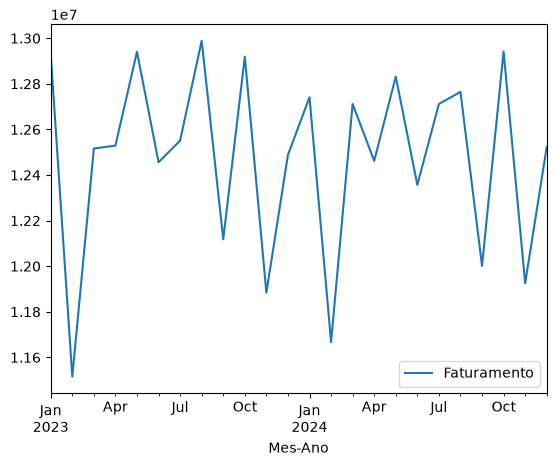

In [72]:
df_analise["Mes-Ano"] = df_analise["Data"].dt.to_period("M")
df_vendas_mes = df_analise[["Mes-Ano", "Faturamento"]].groupby("Mes-Ano").sum()
df_vendas_mes.plot()
display(df_vendas_mes)

